09_salinas_spatial_split_training.ipynb

1. Imports / setup
2. Load Salinas cube + ground truth
3. Create spatial train/validation/test regions
4. Visualize the split
5. Extract patches
6. Create PyTorch datasets/loaders
7. Train CNN
8. Train Hybrid
9. Train Transformer
10. Evaluate on SAME spatial test set
11. Accuracy + Macro-F1 + per-class F1
12. Confusion matrices
13. Save best checkpoints


In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import DataLoader
from tqdm.auto import tqdm

from dfm.data.salinas import (
    SALINAS_CLASS_NAMES,
    SalinasPatchDataset,
    labeled_pixel_indices,
    load_salinas,
    stratified_train_test_split,
)
from dfm.models.hybrid import HybridSpatialSpectralClassifier
from dfm.training.metrics import accuracy_score, macro_f1_score
from dfm.training.profiling import count_parameters

c:\Users\Dines\Documents\Codex\2026-05-15\files-mentioned-by-the-user-dataset0\dense-forest-monitoring\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


````markdown
# 1. Project Setup and Required Libraries

This cell prepares the notebook environment and imports all libraries and project-specific components required for the **spatial evaluation experiment on the Salinas hyperspectral dataset**.

The purpose of this first cell is not to perform any machine-learning computation yet. Instead, it establishes the environment in which the rest of the experiment will run.

The imports can be divided into four groups:

1. **Project/path management**
2. **General numerical and data-processing libraries**
3. **PyTorch and training utilities**
4. **Project-specific dataset, model, metric, and profiling utilities**

---

## 1.1 Project Path Configuration

```python
from pathlib import Path
import sys
````

`Path` from Python's `pathlib` module is used to work with directories and file paths in a platform-independent way.

This is preferable to manually constructing paths as strings such as:

```text
"C:/Users/.../dense-forest-monitoring/src"
```

because `Path` handles operating-system-specific path conventions automatically.

`sys` is imported because we need to modify Python's module search path.

---

## 1.2 Identifying the Project Root

```python
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
```

`Path.cwd()` returns the **current working directory** from which the notebook is running.

The code handles two possible situations.

### Case 1: The notebook is being executed from the `notebooks/` directory

For example:

```text
dense-forest-monitoring/
│
├── data/
├── outputs/
├── src/
│   └── dfm/
│
└── notebooks/
    └── spatial_experiment.ipynb
```

If the current working directory is:

```text
dense-forest-monitoring/notebooks/
```

then the code takes its parent:

```text
dense-forest-monitoring/
```

and stores it in:

```python
PROJECT_ROOT
```

### Case 2: The notebook is already being executed from the project root

If the current working directory is:

```text
dense-forest-monitoring/
```

then it is used directly as `PROJECT_ROOT`.

Therefore, regardless of where the notebook is launched from, the rest of the code can refer to files relative to:

```python
PROJECT_ROOT
```

This makes the notebook more portable and reproducible.

---

## 1.3 Adding the Project's `src` Directory to Python's Search Path

```python
sys.path.insert(0, str(PROJECT_ROOT / "src"))
```

Python maintains a list of directories called `sys.path`. When Python encounters an import such as:

```python
from dfm.models.hybrid import HybridSpatialSpectralClassifier
```

it searches these directories to find the requested package.

Our project-specific source code is located under:

```text
src/
└── dfm/
    ├── data/
    ├── models/
    └── training/
```

Therefore, we add the project's `src` directory to `sys.path`.

The `0` means that `src` is inserted at the beginning of the search path.

This allows the notebook to import the project's own modules without requiring the entire project to be installed as a Python package.

---

# 2. General Numerical and Visualization Libraries

```python
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
```

### NumPy

`numpy` is used for numerical computation and multidimensional arrays.

This is particularly important for hyperspectral image processing because the Salinas image is represented as a multidimensional numerical array.

For example, the hyperspectral cube can conceptually be represented as:

[
H \times W \times C
]

where:

* (H) = image height,
* (W) = image width,
* (C) = number of spectral bands.

NumPy is also used later for:

* storing pixel coordinates,
* manipulating class labels,
* concatenating predictions,
* creating spatial masks,
* controlling random seeds,
* numerical calculations during dataset construction.

The alias `np` is simply a standard shorthand for NumPy.

---

### Pandas

```python
import pandas as pd
```

Pandas is used for tabular data manipulation.

In this experiment, it will mainly be used later to store the model's training history.

For example, after training we may have a table such as:

```text
epoch | train_loss | val_accuracy | val_macro_f1
--------------------------------------------------
1     | ...        | ...          | ...
2     | ...        | ...          | ...
3     | ...        | ...          | ...
```

A Pandas DataFrame makes this information easy to:

* inspect,
* save as CSV,
* plot,
* compare across experiments.

---

### Matplotlib

```python
import matplotlib.pyplot as plt
```

Matplotlib is used to visualize the experiment.

Later it will be used for plots such as:

* training loss versus epoch,
* validation accuracy versus epoch,
* validation Macro-F1 versus epoch,
* the selected best epoch,
* spatial train/validation/test regions.

These visualizations are useful for understanding model convergence and diagnosing possible overfitting.

---

# 3. PyTorch and Training Utilities

```python
import torch
from torch import nn
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
```

## PyTorch

```python
import torch
```

PyTorch is the deep-learning framework used to train the Hybrid spatial-spectral classifier.

It provides:

* tensor operations,
* automatic differentiation,
* neural-network computation,
* GPU acceleration,
* model parameter management.

The experiment can therefore run on either the CPU or a CUDA-compatible NVIDIA GPU.

In this experiment, the training is performed using the NVIDIA GeForce RTX 2050.

---

## Neural-Network Components

```python
from torch import nn
```

`torch.nn` contains PyTorch's neural-network building blocks.

It provides components such as:

* convolutional layers,
* linear layers,
* normalization layers,
* activation functions,
* dropout,
* loss functions,
* Transformer components.

The Hybrid model itself is implemented in the project's model module, but its underlying components are built using PyTorch's neural-network framework.

---

## DataLoader

```python
from torch.utils.data import DataLoader
```

`DataLoader` is responsible for feeding the dataset to the neural network in **mini-batches**.

The model does not process the entire Salinas dataset at once.

Instead, samples are grouped into batches.

For example, with:

```python
batch_size = 128
```

the model receives up to 128 hyperspectral patches in one forward pass.

Mini-batch training is useful because it:

1. reduces memory requirements,
2. allows efficient GPU computation,
3. provides multiple gradient updates during training,
4. makes it possible to train on datasets larger than GPU memory.

The DataLoader will also later be configured differently for training and evaluation:

* training → shuffled batches,
* validation → ordered batches,
* test → ordered batches.

---

## tqdm

```python
from tqdm.auto import tqdm
```

`tqdm` provides progress bars around loops.

During training, for example, instead of seeing a loop run with no feedback, the notebook can display how many batches have already been processed.

`tqdm` does not affect the model's predictions or learning process. It is only a monitoring and usability utility.

---

# 4. Salinas Dataset Utilities

```python
from dfm.data.salinas import (
    SALINAS_CLASS_NAMES,
    SalinasPatchDataset,
    labeled_pixel_indices,
    load_salinas,
    stratified_train_test_split,
)
```

These functions and classes are part of the project's own Salinas data-processing module.

They contain the dataset-specific logic needed to load the hyperspectral scene, identify labeled pixels, construct spatial-spectral patches, and perform dataset splitting.

---

## `SALINAS_CLASS_NAMES`

```python
SALINAS_CLASS_NAMES
```

This contains the names of the 16 land-cover classes in the Salinas dataset.

The class names are useful because the model ultimately produces a prediction among these 16 categories.

They are also needed later when reporting:

* class distributions,
* per-class performance,
* confusion matrices,
* class-specific F1 scores.

The number of classes can therefore be obtained from:

```python
len(SALINAS_CLASS_NAMES)
```

which is 16 for this experiment.

---

## `SalinasPatchDataset`

```python
SalinasPatchDataset
```

This is the project's custom PyTorch dataset for converting labeled pixels into **spatial-spectral patches**.

The model does not classify a pixel using only its 204-dimensional spectrum.

Instead, each labeled center pixel is associated with a spatial neighborhood.

In this experiment, the patch size is later set to:

[
15\times15
]

and the Salinas image contains 204 spectral bands.

Therefore, one input sample contains:

[
204\times15\times15
]

values in PyTorch's channel-first representation.

Conceptually:

```text
One labeled center pixel
        ↓
15 × 15 spatial neighborhood
        ↓
204 spectral measurements at every location
        ↓
204 × 15 × 15 input tensor
        ↓
Hybrid spatial-spectral model
```

The custom dataset performs this patch extraction when samples are requested.

---

## `labeled_pixel_indices`

```python
labeled_pixel_indices
```

The Salinas label map contains both labeled and unlabeled pixels.

This function identifies the pixels that have valid ground-truth class labels.

It returns information corresponding to:

```text
row coordinate
column coordinate
class label
```

For example, conceptually:

```text
(row=120, column=350, class=7)
(row=121, column=350, class=7)
(row=122, column=351, class=3)
...
```

The row and column coordinates are especially important in this notebook because this is a **spatial evaluation experiment**.

Unlike a conventional random pixel split, we need to know where every labeled pixel is located so that neighboring pixels can be grouped into spatial blocks.

---

## `load_salinas`

```python
load_salinas
```

This function loads the Salinas hyperspectral scene and its corresponding ground-truth labels.

The resulting scene object contains the information required for the experiment, including:

* the hyperspectral data cube,
* the label map,
* the number of spectral bands,
* the class names.

The hyperspectral cube can be viewed as:

[
H\times W\times C
]

where (C=204) spectral bands are available for every spatial location.

---

## `stratified_train_test_split`

```python
stratified_train_test_split
```

This utility performs a **pixel-level stratified split**, where samples from each class are distributed between training and testing sets.

This function was useful for the earlier random-pixel evaluation experiment.

However, it is important to distinguish that experiment from the experiment in this notebook.

### Earlier experiment

The data was split approximately as:

```text
individual labeled pixels
        ↓
stratified random split
        ↓
training / testing
```

This can result in neighboring pixels appearing in both training and testing.

### Current experiment

The objective is different:

```text
individual labeled pixels
        ↓
group into 32 × 32 spatial blocks
        ↓
assign complete blocks
        ↓
training / validation / testing
```

The current notebook therefore uses a **spatial block-based split** rather than a simple random pixel split.

The import of `stratified_train_test_split` is retained because it is part of the project's existing Salinas utilities and may be useful for reproducing or comparing against the earlier baseline experiment.

---

# 5. Hybrid Model

```python
from dfm.models.hybrid import HybridSpatialSpectralClassifier
```

`HybridSpatialSpectralClassifier` is the main model evaluated in this notebook.

The model is designed to learn two complementary types of information from hyperspectral data:

### Spatial information

A CNN-based branch analyzes the local (15\times15) neighborhood around the target pixel.

It can learn spatial patterns such as:

* local texture,
* boundaries,
* shapes,
* neighboring land-cover structure.

### Spectral information

A Transformer-based branch processes information across the spectral bands.

It can learn relationships between different wavelengths rather than treating each spectral band as completely independent.

### Feature fusion

The outputs of the spatial and spectral branches are combined using the model's gated fusion mechanism.

The resulting fused representation is then passed to a classification head that predicts one of the 16 Salinas classes.

Conceptually:

```text
                 Input patch
              204 × 15 × 15
                     │
          ┌──────────┴──────────┐
          ↓                     ↓
    Spatial CNN           Spectral Transformer
          ↓                     ↓
   spatial features       spectral features
          └──────────┬──────────┘
                     ↓
                Gated Fusion
                     ↓
              Classification
                     ↓
                  16 classes
```

This architecture is the reason the experiment is referred to as a **hybrid spatial-spectral model**.

---

# 6. Evaluation Metrics

```python
from dfm.training.metrics import accuracy_score, macro_f1_score
```

These functions provide the evaluation metrics used to measure classification performance.

---

## Accuracy

Accuracy measures the fraction of predictions that are correct:

[
Accuracy =
\frac{\text{Number of correct predictions}}
{\text{Total number of predictions}}
]

For example, if the model correctly classifies 9,000 out of 10,000 test samples:

[
Accuracy = \frac{9000}{10000}=0.90
]

or 90%.

Accuracy is useful as an overall measure, but it can be misleading when classes are imbalanced.

---

## Macro-F1

Macro-F1 is particularly important for this experiment because the 16 Salinas classes do not have equal numbers of samples.

For each class, we calculate its F1 score:

[
F1 =
\frac{2PR}{P+R}
]

where:

* (P) = precision,
* (R) = recall.

Macro-F1 then takes the arithmetic mean of the F1 scores across all classes:

[
Macro\text{-}F1 =
\frac{1}{K}
\sum_{k=1}^{K}F1_k
]

where (K=16).

This means that every class contributes equally to the final Macro-F1, regardless of how many samples it contains.

Therefore, Macro-F1 is particularly useful here for determining whether the model performs well across both common and relatively rare land-cover classes.

---

# 7. Model Parameter Counting

```python
from dfm.training.profiling import count_parameters
```

`count_parameters` is a project utility used later to determine how many trainable parameters the Hybrid model contains.

The parameter count provides an indication of model size and complexity.

This becomes useful when comparing the Hybrid model with the CNN and Transformer baselines.

For example, later we can report something conceptually like:

```text
Model                    Parameters
CNN baseline             ...
Transformer baseline     ...
Hybrid                   ...
```

Parameter count alone does not determine model quality, but it is an important efficiency and complexity metric when comparing architectures.

---

# Overall Purpose of This Cell

This cell establishes everything required for the rest of the experiment:

```text
Project structure
       ↓
Numerical / visualization tools
       ↓
PyTorch training environment
       ↓
Salinas dataset utilities
       ↓
Hybrid spatial-spectral model
       ↓
Evaluation metrics
       ↓
Model profiling
```

No model training or evaluation occurs in this cell.

It simply prepares the environment so that the subsequent cells can:

1. load the Salinas hyperspectral scene,
2. identify labeled pixels,
3. construct spatially separated data splits,
4. create (15\times15) spatial-spectral patches,
5. train the Hybrid model,
6. select the best model using validation data,
7. evaluate it once on the held-out spatial test set.

```
```


In [2]:
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

data_dir = PROJECT_ROOT / "data" / "raw" / "salinas"
scene = load_salinas(data_dir, download=True)
rows, cols, labels = labeled_pixel_indices(scene.labels)

print("Cube shape (H, W, C):", scene.cube.shape)
print("Label map shape:", scene.labels.shape)
print("Bands:", scene.bands)
print("Classes:", len(scene.class_names))

Cube shape (H, W, C): (512, 217, 204)
Label map shape: (512, 217)
Bands: 204
Classes: 16


In [3]:
import inspect
import dfm.data.salinas as salinas

print(inspect.getsource(salinas.SalinasPatchDataset))

class SalinasPatchDataset:
    """Lazy centered-patch dataset for labeled Salinas pixels."""

    def __init__(
        self,
        scene: SalinasScene,
        indices: np.ndarray | None = None,
        patch_size: int = 15,
        normalize: bool = True,
    ) -> None:
        if patch_size <= 0 or patch_size % 2 == 0:
            raise ValueError("patch_size must be a positive odd integer.")

        rows, cols, labels = labeled_pixel_indices(scene.labels)
        if indices is None:
            indices = np.arange(len(labels))

        self.rows = rows[indices]
        self.cols = cols[indices]
        self.labels = labels[indices]
        self.patch_size = patch_size
        self.radius = patch_size // 2

        cube = normalize_cube_per_band(scene.cube) if normalize else scene.cube.astype(np.float32)
        self.padded_cube = np.pad(
            cube,
            ((self.radius, self.radius), (self.radius, self.radius), (0, 0)),
            mode="reflect",
        )

    def 

In [4]:
print(inspect.getsource(salinas.stratified_train_test_split))

def stratified_train_test_split(
    labels: np.ndarray,
    train_fraction: float = 0.1,
    seed: int = 42,
) -> tuple[np.ndarray, np.ndarray]:
    """Create stratified train/test indices without requiring scikit-learn."""

    if not 0.0 < train_fraction < 1.0:
        raise ValueError("train_fraction must be between 0 and 1.")

    rng = np.random.default_rng(seed)
    train_indices: list[np.ndarray] = []
    test_indices: list[np.ndarray] = []

    for class_id in np.unique(labels):
        class_indices = np.where(labels == class_id)[0]
        rng.shuffle(class_indices)
        train_count = max(1, int(round(len(class_indices) * train_fraction)))
        train_indices.append(class_indices[:train_count])
        test_indices.append(class_indices[train_count:])

    train = np.concatenate(train_indices)
    test = np.concatenate(test_indices)
    rng.shuffle(train)
    rng.shuffle(test)
    return train, test



In [5]:
print(inspect.getsource(salinas.labeled_pixel_indices))

def labeled_pixel_indices(labels: np.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Return row, column, and zero-based class arrays for labeled pixels."""

    rows, cols = np.where(labels > 0)
    y = labels[rows, cols].astype(np.int64) - 1
    return rows, cols, y



In [6]:
def spatial_train_val_test_split(
    rows,
    cols,
    labels,
    block_size=32,
    train_fraction=0.6,
    val_fraction=0.2,
    seed=42,
):
    """
    Split labeled Salinas pixels into spatially separated
    train/validation/test sets.

    The split is performed at the spatial-block level,
    not independently at the pixel level.
    """

    if train_fraction + val_fraction >= 1.0:
        raise ValueError("train_fraction + val_fraction must be < 1.")

    # Assign every labeled pixel to a spatial block
    block_rows = rows // block_size
    block_cols = cols // block_size

    block_ids = np.stack(
        [block_rows, block_cols],
        axis=1
    )

    # Find unique spatial blocks
    unique_blocks = np.unique(block_ids, axis=0)

    rng = np.random.default_rng(seed)
    rng.shuffle(unique_blocks)

    n_blocks = len(unique_blocks)

    n_train = int(round(train_fraction * n_blocks))
    n_val = int(round(val_fraction * n_blocks))

    train_blocks = unique_blocks[:n_train]
    val_blocks = unique_blocks[n_train:n_train + n_val]
    test_blocks = unique_blocks[n_train + n_val:]

    def get_indices(blocks):
        mask = np.zeros(len(rows), dtype=bool)

        for br, bc in blocks:
            mask |= (
                (block_rows == br) &
                (block_cols == bc)
            )

        return np.where(mask)[0]

    train_indices = get_indices(train_blocks)
    val_indices = get_indices(val_blocks)
    test_indices = get_indices(test_blocks)

    # Shuffle indices within each split
    rng.shuffle(train_indices)
    rng.shuffle(val_indices)
    rng.shuffle(test_indices)

    return train_indices, val_indices, test_indices

In [7]:
train_indices, val_indices, test_indices = spatial_train_val_test_split(
    rows,
    cols,
    labels,
    block_size=32,
    train_fraction=0.6,
    val_fraction=0.2,
    seed=SEED,
)

In [8]:
patch_size = 15

train_dataset = SalinasPatchDataset(
    scene,
    indices=train_indices,
    patch_size=patch_size,
)

val_dataset = SalinasPatchDataset(
    scene,
    indices=val_indices,
    patch_size=patch_size,
)

test_dataset = SalinasPatchDataset(
    scene,
    indices=test_indices,
    patch_size=patch_size,
)

In [9]:
train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True,
    num_workers=0,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=256,
    shuffle=False,
    num_workers=0,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=256,
    shuffle=False,
    num_workers=0,
)

In [10]:
print("Train samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))
print("Test samples:", len(test_dataset))

Train samples: 32732
Validation samples: 10678
Test samples: 10719


In [11]:
from collections import Counter

def print_class_distribution(indices, name):
    class_labels = labels[indices]

    counts = Counter(class_labels)

    print(f"\n{name}")
    print("-" * 30)

    for class_id in range(len(SALINAS_CLASS_NAMES)):
        print(
            f"{class_id + 1:2d} "
            f"{SALINAS_CLASS_NAMES[class_id]:30s} "
            f"{counts.get(class_id, 0)}"
        )

print_class_distribution(train_indices, "TRAIN")
print_class_distribution(val_indices, "VALIDATION")
print_class_distribution(test_indices, "TEST")


TRAIN
------------------------------
 1 Brocoli_green_weeds_1          798
 2 Brocoli_green_weeds_2          2855
 3 Fallow                         1555
 4 Fallow_rough_plow              586
 5 Fallow_smooth                  1822
 6 Stubble                        2707
 7 Celery                         2457
 8 Grapes_untrained               7905
 9 Soil_vinyard_develop           3022
10 Corn_senesced_green_weeds      2123
11 Lettuce_romaine_4wk            325
12 Lettuce_romaine_5wk            736
13 Lettuce_romaine_6wk            639
14 Lettuce_romaine_7wk            979
15 Vinyard_untrained              2416
16 Vinyard_vertical_trellis       1807

VALIDATION
------------------------------
 1 Brocoli_green_weeds_1          484
 2 Brocoli_green_weeds_2          661
 3 Fallow                         194
 4 Fallow_rough_plow              141
 5 Fallow_smooth                  493
 6 Stubble                        1252
 7 Celery                         1122
 8 Grapes_untrained              

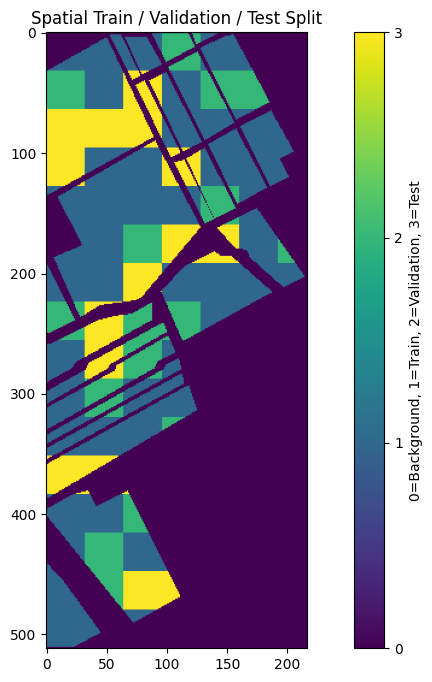

In [12]:
split_map = np.zeros_like(scene.labels)

# scene.labels uses 1-based class labels,
# so we can use separate values for visualization.

for idx in train_indices:
    split_map[rows[idx], cols[idx]] = 1

for idx in val_indices:
    split_map[rows[idx], cols[idx]] = 2

for idx in test_indices:
    split_map[rows[idx], cols[idx]] = 3

plt.figure(figsize=(12, 8))
plt.imshow(split_map)
plt.title("Spatial Train / Validation / Test Split")
plt.colorbar(
    ticks=[0, 1, 2, 3],
    label="0=Background, 1=Train, 2=Validation, 3=Test"
)
plt.show()

In [13]:
def class_block_distribution(rows, cols, labels, block_size=32):

    block_rows = rows // block_size
    block_cols = cols // block_size

    print(f"Block size: {block_size}x{block_size}\n")

    for class_id in range(len(SALINAS_CLASS_NAMES)):

        mask = labels == class_id

        class_blocks = set(
            zip(
                block_rows[mask],
                block_cols[mask]
            )
        )

        print(
            f"{class_id + 1:2d} "
            f"{SALINAS_CLASS_NAMES[class_id]:30s} "
            f"→ {len(class_blocks)} spatial blocks"
        )


class_block_distribution(
    rows,
    cols,
    labels,
    block_size=32
)

Block size: 32x32

 1 Brocoli_green_weeds_1          → 6 spatial blocks
 2 Brocoli_green_weeds_2          → 10 spatial blocks
 3 Fallow                         → 7 spatial blocks
 4 Fallow_rough_plow              → 8 spatial blocks
 5 Fallow_smooth                  → 9 spatial blocks
 6 Stubble                        → 12 spatial blocks
 7 Celery                         → 10 spatial blocks
 8 Grapes_untrained               → 19 spatial blocks
 9 Soil_vinyard_develop           → 14 spatial blocks
10 Corn_senesced_green_weeds      → 9 spatial blocks
11 Lettuce_romaine_4wk            → 7 spatial blocks
12 Lettuce_romaine_5wk            → 9 spatial blocks
13 Lettuce_romaine_6wk            → 8 spatial blocks
14 Lettuce_romaine_7wk            → 7 spatial blocks
15 Vinyard_untrained              → 12 spatial blocks
16 Vinyard_vertical_trellis       → 4 spatial blocks


In [14]:
block_size = 32

block_rows = rows // block_size
block_cols = cols // block_size

block_keys = np.stack(
    [block_rows, block_cols],
    axis=1
)

unique_blocks = np.unique(block_keys, axis=0)

print("Number of spatial blocks:", len(unique_blocks))

Number of spatial blocks: 81


In [15]:
block_class_counts = {}

for br, bc in unique_blocks:

    mask = (
        (block_rows == br) &
        (block_cols == bc)
    )

    counts = np.bincount(
        labels[mask],
        minlength=len(SALINAS_CLASS_NAMES)
    )

    block_class_counts[(br, bc)] = counts

In [16]:
block_class_counts[(3, 4)]

array([  0,   0,   0,   0, 368, 533,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0])

In [17]:
def find_spatial_split(
    rows,
    cols,
    labels,
    block_size=32,
    train_fraction=0.60,
    val_fraction=0.20,
    seed=42,
    n_trials=10000,
):
    rng = np.random.default_rng(seed)

    block_rows = rows // block_size
    block_cols = cols // block_size

    block_keys = np.stack(
        [block_rows, block_cols],
        axis=1
    )

    unique_blocks = np.unique(block_keys, axis=0)

    n_blocks = len(unique_blocks)

    n_train = round(train_fraction * n_blocks)
    n_val = round(val_fraction * n_blocks)

    best_score = np.inf
    best_assignment = None

    # Precompute class counts for each block
    block_counts = []

    for br, bc in unique_blocks:

        mask = (
            (block_rows == br) &
            (block_cols == bc)
        )

        counts = np.bincount(
            labels[mask],
            minlength=len(SALINAS_CLASS_NAMES)
        )

        block_counts.append(counts)

    block_counts = np.asarray(block_counts)

    total_class_counts = block_counts.sum(axis=0)

    for _ in range(n_trials):

        permutation = rng.permutation(n_blocks)

        train_ids = permutation[:n_train]
        val_ids = permutation[n_train:n_train + n_val]
        test_ids = permutation[n_train + n_val:]

        train_counts = block_counts[train_ids].sum(axis=0)
        val_counts = block_counts[val_ids].sum(axis=0)
        test_counts = block_counts[test_ids].sum(axis=0)

        # Every class must occur in every split
        if np.any(train_counts == 0):
            continue

        if np.any(val_counts == 0):
            continue

        if np.any(test_counts == 0):
            continue

        # Compare class proportions with overall distribution
        overall_dist = total_class_counts / total_class_counts.sum()

        train_dist = train_counts / train_counts.sum()
        val_dist = val_counts / val_counts.sum()
        test_dist = test_counts / test_counts.sum()

        distribution_error = (
            np.mean(np.abs(train_dist - overall_dist))
            + np.mean(np.abs(val_dist - overall_dist))
            + np.mean(np.abs(test_dist - overall_dist))
        )

        # Compare number of pixels with desired 60/20/20
        total_pixels = len(labels)

        target_train = train_fraction * total_pixels
        target_val = val_fraction * total_pixels
        target_test = (1 - train_fraction - val_fraction) * total_pixels

        size_error = (
            abs(train_counts.sum() - target_train) / total_pixels
            + abs(val_counts.sum() - target_val) / total_pixels
            + abs(test_counts.sum() - target_test) / total_pixels
        )

        score = distribution_error + size_error

        if score < best_score:
            best_score = score

            best_assignment = (
                unique_blocks[train_ids].copy(),
                unique_blocks[val_ids].copy(),
                unique_blocks[test_ids].copy(),
            )

    if best_assignment is None:
        raise RuntimeError(
            "Could not find a valid spatial split. "
            "Try increasing n_trials or changing block_size."
        )

    train_blocks, val_blocks, test_blocks = best_assignment

    def blocks_to_indices(blocks):

        mask = np.zeros(len(rows), dtype=bool)

        for br, bc in blocks:
            mask |= (
                (block_rows == br) &
                (block_cols == bc)
            )

        return np.where(mask)[0]

    train_indices = blocks_to_indices(train_blocks)
    val_indices = blocks_to_indices(val_blocks)
    test_indices = blocks_to_indices(test_blocks)

    rng.shuffle(train_indices)
    rng.shuffle(val_indices)
    rng.shuffle(test_indices)

    return (
        train_indices,
        val_indices,
        test_indices,
        train_blocks,
        val_blocks,
        test_blocks,
        best_score,
    )

In [18]:
(
    train_indices,
    val_indices,
    test_indices,
    train_blocks,
    val_blocks,
    test_blocks,
    split_score,
) = find_spatial_split(
    rows,
    cols,
    labels,
    block_size=32,
    train_fraction=0.60,
    val_fraction=0.20,
    seed=42,
    n_trials=10000,
)

print("Split score:", split_score)

print("Train samples:", len(train_indices))
print("Validation samples:", len(val_indices))
print("Test samples:", len(test_indices))

Split score: 0.07301944978698473
Train samples: 32337
Validation samples: 10952
Test samples: 10840


In [19]:
print_class_distribution(train_indices, "TRAIN")
print_class_distribution(val_indices, "VALIDATION")
print_class_distribution(test_indices, "TEST")


TRAIN
------------------------------
 1 Brocoli_green_weeds_1          196
 2 Brocoli_green_weeds_2          2010
 3 Fallow                         1411
 4 Fallow_rough_plow              958
 5 Fallow_smooth                  1322
 6 Stubble                        2070
 7 Celery                         2958
 8 Grapes_untrained               7214
 9 Soil_vinyard_develop           2991
10 Corn_senesced_green_weeds      2371
11 Lettuce_romaine_4wk            851
12 Lettuce_romaine_5wk            1351
13 Lettuce_romaine_6wk            528
14 Lettuce_romaine_7wk            821
15 Vinyard_untrained              4624
16 Vinyard_vertical_trellis       661

VALIDATION
------------------------------
 1 Brocoli_green_weeds_1          904
 2 Brocoli_green_weeds_2          1218
 3 Fallow                         269
 4 Fallow_rough_plow              141
 5 Fallow_smooth                  493
 6 Stubble                        1257
 7 Celery                         501
 8 Grapes_untrained              

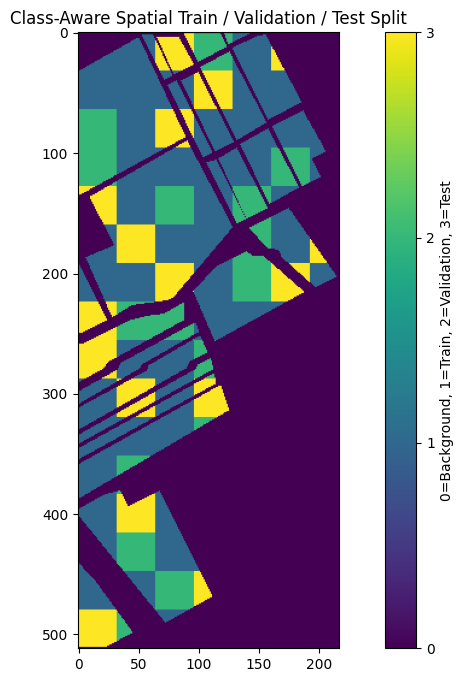

In [20]:
split_map = np.zeros_like(scene.labels)

for idx in train_indices:
    split_map[rows[idx], cols[idx]] = 1

for idx in val_indices:
    split_map[rows[idx], cols[idx]] = 2

for idx in test_indices:
    split_map[rows[idx], cols[idx]] = 3

plt.figure(figsize=(12, 8))
plt.imshow(split_map)

plt.title("Class-Aware Spatial Train / Validation / Test Split")

plt.colorbar(
    ticks=[0, 1, 2, 3],
    label="0=Background, 1=Train, 2=Validation, 3=Test"
)

plt.show()

In [21]:
from scipy.ndimage import binary_erosion

radius = patch_size // 2

split_map = np.zeros_like(scene.labels, dtype=np.uint8)

for idx in train_indices:
    split_map[rows[idx], cols[idx]] = 1

for idx in val_indices:
    split_map[rows[idx], cols[idx]] = 2

for idx in test_indices:
    split_map[rows[idx], cols[idx]] = 3

In [22]:
train_region = split_map == 1
val_region   = split_map == 2
test_region  = split_map == 3

structure = np.ones((2 * radius + 1, 2 * radius + 1), dtype=bool)

train_core = binary_erosion(
    train_region,
    structure=structure
)

val_core = binary_erosion(
    val_region,
    structure=structure
)

test_core = binary_erosion(
    test_region,
    structure=structure
)

In [23]:
train_indices_buffered = np.array([
    i for i in train_indices
    if train_core[rows[i], cols[i]]
])

val_indices_buffered = np.array([
    i for i in val_indices
    if val_core[rows[i], cols[i]]
])

test_indices_buffered = np.array([
    i for i in test_indices
    if test_core[rows[i], cols[i]]
])

In [24]:
print("Original train:", len(train_indices))
print("Buffered train:", len(train_indices_buffered))

print("Original val:", len(val_indices))
print("Buffered val:", len(val_indices_buffered))

print("Original test:", len(test_indices))
print("Buffered test:", len(test_indices_buffered))

Original train: 32337
Buffered train: 6658
Original val: 10952
Buffered val: 2227
Original test: 10840
Buffered test: 1136


In [25]:
print_class_distribution(
    train_indices_buffered,
    "BUFFERED TRAIN"
)

print_class_distribution(
    val_indices_buffered,
    "BUFFERED VALIDATION"
)

print_class_distribution(
    test_indices_buffered,
    "BUFFERED TEST"
)


BUFFERED TRAIN
------------------------------
 1 Brocoli_green_weeds_1          0
 2 Brocoli_green_weeds_2          450
 3 Fallow                         236
 4 Fallow_rough_plow              0
 5 Fallow_smooth                  0
 6 Stubble                        154
 7 Celery                         546
 8 Grapes_untrained               2294
 9 Soil_vinyard_develop           404
10 Corn_senesced_green_weeds      293
11 Lettuce_romaine_4wk            0
12 Lettuce_romaine_5wk            0
13 Lettuce_romaine_6wk            0
14 Lettuce_romaine_7wk            0
15 Vinyard_untrained              2242
16 Vinyard_vertical_trellis       39

BUFFERED VALIDATION
------------------------------
 1 Brocoli_green_weeds_1          21
 2 Brocoli_green_weeds_2          409
 3 Fallow                         0
 4 Fallow_rough_plow              0
 5 Fallow_smooth                  7
 6 Stubble                        19
 7 Celery                         2
 8 Grapes_untrained               324
 9 Soil_viny

In [26]:
patch_size = 15

train_dataset = SalinasPatchDataset(
    scene,
    indices=train_indices,
    patch_size=patch_size,
)

val_dataset = SalinasPatchDataset(
    scene,
    indices=val_indices,
    patch_size=patch_size,
)

test_dataset = SalinasPatchDataset(
    scene,
    indices=test_indices,
    patch_size=patch_size,
)

In [27]:
train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True,
    num_workers=0,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=256,
    shuffle=False,
    num_workers=0,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=256,
    shuffle=False,
    num_workers=0,
)

In [28]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: NVIDIA GeForce RTX 2050


In [29]:
!nvidia-smi

Wed Aug 12 05:39:25 2026       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 516.40       Driver Version: 516.40       CUDA Version: 11.7     |
|-------------------------------+----------------------+----------------------+
| GPU  Name            TCC/WDDM | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  NVIDIA GeForce ... WDDM  | 00000000:01:00.0 Off |                  N/A |
| N/A   72C    P0     9W /  N/A |      0MiB /  4096MiB |      0%      Default |
|                               |                      |                  N/A |
+-------------------------------+----------------------+----------------------+
                                                                               
+-------

In [30]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("PyTorch CUDA version:", torch.version.cuda)
print("GPU count:", torch.cuda.device_count())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.5.1+cu118
CUDA available: True
PyTorch CUDA version: 11.8
GPU count: 1
GPU: NVIDIA GeForce RTX 2050


In [31]:
import sys
print(sys.executable)

c:\Users\Dines\Documents\Codex\2026-05-15\files-mentioned-by-the-user-dataset0\dense-forest-monitoring\.venv\Scripts\python.exe


In [32]:
model = HybridSpatialSpectralClassifier(
    in_channels=scene.bands,
    num_classes=len(SALINAS_CLASS_NAMES),
    feature_dim=128,
    spectral_depth=2,
    spectral_heads=4,
    fusion="gated",
    dropout=0.1,
    max_bands=256,
).to(device)

print(model)
print("Trainable parameters:", count_parameters(model))

HybridSpatialSpectralClassifier(
  (spatial): SpatialCNNBranch(
    (net): Sequential(
      (0): Conv2d(204, 64, kernel_size=(1, 1), stride=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): GELU(approximate='none')
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): GELU(approximate='none')
      (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (8): GELU(approximate='none')
      (9): AdaptiveAvgPool2d(output_size=1)
      (10): Flatten(start_dim=1, end_dim=-1)
    )
  )
  (spectral): SpectralAttentionBranch(
    (value_projection): Linear(in_features=1, out_features=128, bias=True)
    (band_embedding): Embedding(256, 128)
    (encoder): TransformerEncoder(
      (layers): ModuleLi

In [33]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4,
)

In [34]:
def train_one_epoch(model, loader):

    model.train()

    total_loss = 0.0
    total = 0

    for x, y in tqdm(loader, leave=False):

        x = x.to(device=device, dtype=torch.float32)
        y = y.to(device=device, dtype=torch.long)

        optimizer.zero_grad(set_to_none=True)

        logits = model(x)

        loss = criterion(logits, y)

        loss.backward()

        optimizer.step()

        total_loss += loss.item() * x.shape[0]
        total += x.shape[0]

    return total_loss / total


@torch.no_grad()
def evaluate(model, loader):

    model.eval()

    all_true = []
    all_pred = []

    for x, y in tqdm(loader, leave=False):

        x = x.to(device=device, dtype=torch.float32)

        logits = model(x)

        pred = logits.argmax(dim=1)

        all_pred.append(pred.cpu().numpy())
        all_true.append(y.numpy())

    y_true = np.concatenate(all_true)
    y_pred = np.concatenate(all_pred)

    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": macro_f1_score(
            y_true,
            y_pred,
            num_classes=len(SALINAS_CLASS_NAMES),
        ),
    }

In [35]:
val_metrics = evaluate(model, val_loader)

print(val_metrics)

{'accuracy': 0.06099342585829072, 'macro_f1': 0.015307989109961609}


In [36]:
epochs = 50
patience = 8

history = []

best_macro_f1 = -1.0
best_epoch = None
best_state = None

epochs_without_improvement = 0

In [37]:
model.eval()

x, y = next(iter(val_loader))

x = x.to(device=device, dtype=torch.float32)

with torch.no_grad():
    logits = model(x)

print("Input:", x.shape)
print("Output:", logits.shape)

Input: torch.Size([256, 204, 15, 15])
Output: torch.Size([256, 16])


In [38]:
pred = logits.argmax(dim=1)

print(pred.shape)

torch.Size([256])


In [39]:
for epoch in range(1, epochs + 1):

    train_loss = train_one_epoch(
        model,
        train_loader
    )

    # IMPORTANT:
    # We evaluate validation, NOT test.
    val_metrics = evaluate(
        model,
        val_loader
    )

    row = {
        "epoch": epoch,
        "train_loss": train_loss,
        "val_accuracy": val_metrics["accuracy"],
        "val_macro_f1": val_metrics["macro_f1"],
    }

    history.append(row)

    print(
        f"Epoch {epoch:02d} | "
        f"Loss: {train_loss:.4f} | "
        f"Val Acc: {val_metrics['accuracy']:.4f} | "
        f"Val Macro-F1: {val_metrics['macro_f1']:.4f}"
    )

    # Best validation checkpoint
    if val_metrics["macro_f1"] > best_macro_f1:

        best_macro_f1 = val_metrics["macro_f1"]
        best_epoch = epoch
        epochs_without_improvement = 0

        best_state = {
            key: value.detach().cpu().clone()
            for key, value in model.state_dict().items()
        }

        print("  ✓ New best model")

    else:

        epochs_without_improvement += 1

    # Early stopping
    if epochs_without_improvement >= patience:

        print(
            f"\nEarly stopping at epoch {epoch}"
        )

        break

  0%|          | 0/253 [00:00<?, ?it/s]

Epoch 01 | Loss: 0.2592 | Val Acc: 0.9584 | Val Macro-F1: 0.9054
  ✓ New best model


Epoch 02 | Loss: 0.0475 | Val Acc: 0.9333 | Val Macro-F1: 0.8722


Epoch 03 | Loss: 0.0420 | Val Acc: 0.8492 | Val Macro-F1: 0.8377


Epoch 04 | Loss: 0.0177 | Val Acc: 0.8251 | Val Macro-F1: 0.8330


Epoch 05 | Loss: 0.0150 | Val Acc: 0.8313 | Val Macro-F1: 0.8363


Epoch 06 | Loss: 0.0273 | Val Acc: 0.7552 | Val Macro-F1: 0.7625


Epoch 07 | Loss: 0.0134 | Val Acc: 0.8658 | Val Macro-F1: 0.8390


Epoch 08 | Loss: 0.0179 | Val Acc: 0.8243 | Val Macro-F1: 0.8376


Epoch 09 | Loss: 0.0150 | Val Acc: 0.8668 | Val Macro-F1: 0.8409

Early stopping at epoch 9


In [40]:
history_df = pd.DataFrame(history)

print("\nBest epoch:", best_epoch)
print("Best validation Macro-F1:", best_macro_f1)

history_df


Best epoch: 1
Best validation Macro-F1: 0.9054250328694162


,epoch,train_loss,val_accuracy,val_macro_f1
0,1,0.259234,0.958364,0.905425
1,2,0.047547,0.933254,0.872216
2,3,0.041985,0.849160,0.837711
3,4,0.017716,0.825146,0.832952
4,5,0.014977,0.831264,0.836349
5,6,0.027312,0.755205,0.762450
6,7,0.013413,0.865778,0.839027
7,8,0.017894,0.824324,0.837558
8,9,0.015014,0.866782,0.840904


In [53]:
model.load_state_dict(best_state)

print(
    f"Restored best model from epoch {best_epoch}"
)

Restored best model from epoch 1


In [54]:
test_metrics = evaluate(
    model,
    test_loader
)

print("\n" + "=" * 50)
print("FINAL SPATIAL TEST RESULTS")
print("=" * 50)

print(
    f"Accuracy : {test_metrics['accuracy']:.4f}"
)

print(
    f"Macro-F1 : {test_metrics['macro_f1']:.4f}"
)


FINAL SPATIAL TEST RESULTS
Accuracy : 0.9532
Macro-F1 : 0.9206


In [55]:
outputs_dir = PROJECT_ROOT / "outputs" / "salinas"

outputs_dir.mkdir(
    parents=True,
    exist_ok=True
)

In [56]:
history_df.to_csv(
    outputs_dir / "hybrid_spatial_history.csv",
    index=False
)

In [45]:
torch.save(
    {
        "model_state_dict": best_state,
        "best_epoch": best_epoch,
        "best_val_macro_f1": best_macro_f1,
        "test_accuracy": test_metrics["accuracy"],
        "test_macro_f1": test_metrics["macro_f1"],
        "class_names": SALINAS_CLASS_NAMES,
        "patch_size": patch_size,
        "bands": scene.bands,
        "seed": SEED,
    },
    outputs_dir / "hybrid_spatial_best.pt",
)

In [57]:
checkpoint_path = outputs_dir / "hybrid_spatial_best.pt"

if best_state is None:
    raise RuntimeError(
        "best_state is None — the best model weights are not available in memory."
    )

torch.save(
    {
        "model_state_dict": best_state,
        "best_epoch": best_epoch,
        "best_val_macro_f1": best_macro_f1,
        "class_names": SALINAS_CLASS_NAMES,
        "patch_size": patch_size,
        "bands": scene.bands,
        "seed": SEED,
    },
    checkpoint_path,
)

print("Saved:", checkpoint_path)

Saved: c:\Users\Dines\Documents\Codex\2026-05-15\files-mentioned-by-the-user-dataset0\dense-forest-monitoring\outputs\salinas\hybrid_spatial_best.pt


In [58]:
checkpoint_check = torch.load(
    checkpoint_path,
    map_location="cpu"
)

print("Best epoch:", checkpoint_check["best_epoch"])
print("Best Val Macro-F1:", checkpoint_check["best_val_macro_f1"])
print("Weights type:", type(checkpoint_check["model_state_dict"]))
print("Number of tensors:", len(checkpoint_check["model_state_dict"]))

Best epoch: 1
Best Val Macro-F1: 0.9054250328694162
Weights type: <class 'dict'>
Number of tensors: 56


C:\Users\Dines\AppData\Local\Temp\ipykernel_26772\117576302.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint_check = torch.load(


In [59]:
model.load_state_dict(checkpoint_check["model_state_dict"])
model.to(device)
model.eval()

print("Best epoch:", checkpoint_check["best_epoch"])
print("Best validation Macro-F1:", checkpoint_check["best_val_macro_f1"])

Best epoch: 1
Best validation Macro-F1: 0.9054250328694162


NameError: name 'collect_predictions' is not defined

In [67]:
np.savez(
    outputs_dir / "salinas_spatial_split_seed42.npz",
    train_indices=train_indices,
    val_indices=val_indices,
    test_indices=test_indices,
)

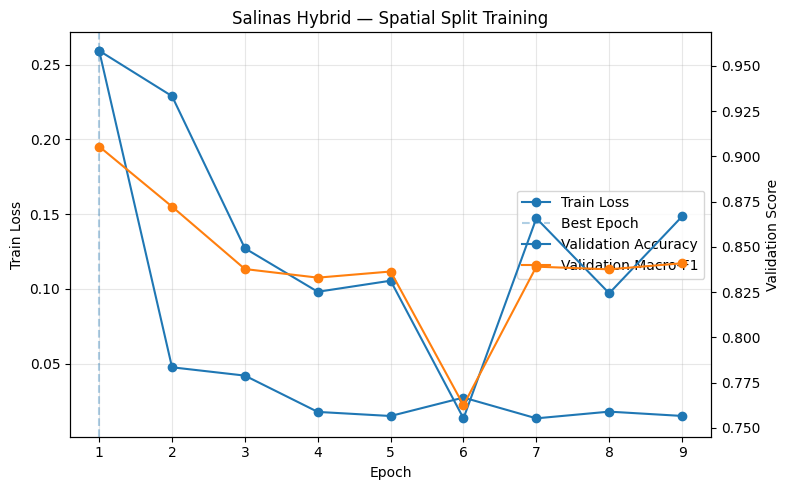

In [52]:
fig, ax1 = plt.subplots(figsize=(8, 5))

ax1.plot(
    history_df["epoch"],
    history_df["train_loss"],
    marker="o",
    label="Train Loss",
)

ax1.set_xlabel("Epoch")
ax1.set_ylabel("Train Loss")
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()

ax2.plot(
    history_df["epoch"],
    history_df["val_accuracy"],
    marker="o",
    label="Validation Accuracy",
)

ax2.plot(
    history_df["epoch"],
    history_df["val_macro_f1"],
    marker="o",
    label="Validation Macro-F1",
)

if best_epoch is not None:
    ax1.axvline(
        best_epoch,
        linestyle="--",
        alpha=0.35,
        label="Best Epoch",
    )

ax2.set_ylabel("Validation Score")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="center right",
)

plt.title(
    "Salinas Hybrid — Spatial Split Training"
)

plt.tight_layout()

plt.show()

## Spatial Split Training Results

The Hybrid Spatial-Spectral Classifier was trained using the spatially separated
train/validation/test partition. Model selection was performed exclusively using
validation Macro-F1, while the test set was reserved for the final evaluation.

The model achieved its best validation performance at epoch 1, with a validation
accuracy of 95.84% and validation Macro-F1 of 90.54%.

Validation performance subsequently fluctuated and did not exceed the epoch-1
Macro-F1. Early stopping therefore terminated training at epoch 9, after eight
epochs without improvement.

The best validation checkpoint was restored before performing the final evaluation
on the held-out spatial test set.

The resulting spatial test performance was:

- Accuracy: 95.32%
- Macro-F1: 92.06%

The close agreement between validation and test accuracy indicates that the selected
checkpoint generalized well to the held-out spatial regions. The slightly higher
test Macro-F1 compared with validation Macro-F1 is possible because the two
partitions contain different spatial regions and class compositions.

## 22. Restoring the Best Validation Checkpoint

The training process stores a copy of the model parameters whenever validation
Macro-F1 improves.

The best checkpoint is selected using the validation set only. The test set is
not used for checkpoint selection.

Here, we restore the parameters corresponding to the best validation Macro-F1
before performing detailed analysis of the final spatial test predictions.

This is important because the parameters remaining in the model after the final
training epoch are not necessarily the parameters that achieved the best
validation performance.

The evaluation protocol is therefore:

\[
\text{Training data}
\rightarrow
\text{Validation-based checkpoint selection}
\rightarrow
\text{Restore best checkpoint}
\rightarrow
\text{Final spatial test evaluation}
\]

For this experiment, the best validation checkpoint occurred at epoch 1.

In [61]:
@torch.no_grad()
def collect_predictions(model, loader):
    model.eval()

    all_true = []
    all_pred = []

    for x, y in tqdm(loader, desc="Collecting test predictions"):
        x = x.to(device=device, dtype=torch.float32)

        logits = model(x)
        pred = logits.argmax(dim=1).cpu().numpy()

        all_pred.append(pred)
        all_true.append(y.numpy())

    y_true = np.concatenate(all_true)
    y_pred = np.concatenate(all_pred)

    return y_true, y_pred

In [62]:
y_test, y_pred = collect_predictions(model, test_loader)

print("Test samples:", len(y_test))
print("Predictions:", len(y_pred))

np.save(outputs_dir / "hybrid_spatial_y_test.npy", y_test)
np.save(outputs_dir / "hybrid_spatial_y_pred.npy", y_pred)

print("Predictions saved.")

Test samples: 10840
Predictions: 10840
Predictions saved.


In [63]:
print("Best epoch:", checkpoint_check["best_epoch"])
print("Best validation Macro-F1:", checkpoint_check["best_val_macro_f1"])

Best epoch: 1
Best validation Macro-F1: 0.9054250328694162


In [64]:
from sklearn.metrics import classification_report

report = classification_report(
    y_test,
    y_pred,
    labels=np.arange(len(SALINAS_CLASS_NAMES)),
    target_names=SALINAS_CLASS_NAMES,
    output_dict=True,
    zero_division=0,
)

per_class_df = pd.DataFrame(report).T

per_class_df

,precision,recall,f1-score,support
Brocoli_green_weeds_1,1.000000,1.000000,1.000000,909.000000
Brocoli_green_weeds_2,1.000000,0.995984,0.997988,498.000000
Fallow,0.976898,1.000000,0.988314,296.000000
Fallow_rough_plow,0.867647,1.000000,0.929134,295.000000
Fallow_smooth,1.000000,0.947856,0.973230,863.000000
Stubble,1.000000,1.000000,1.000000,632.000000
Celery,0.930233,1.000000,0.963855,120.000000
Grapes_untrained,0.979090,0.920662,0.948978,2899.000000
Soil_vinyard_develop,1.000000,1.000000,1.000000,1177.000000
Corn_senesced_green_weeds,0.987835,0.746324,0.850262,544.000000


In [65]:
per_class_df.to_csv(
    outputs_dir / "hybrid_spatial_per_class_metrics.csv"
)

print("Saved per-class metrics.")

Saved per-class metrics.


In [66]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=np.arange(len(SALINAS_CLASS_NAMES))
)

cm_df = pd.DataFrame(
    cm,
    index=SALINAS_CLASS_NAMES,
    columns=SALINAS_CLASS_NAMES
)

cm_df.to_csv(
    outputs_dir / "hybrid_spatial_confusion_matrix.csv"
)

cm_df

,Brocoli_green_weeds_1,Brocoli_green_weeds_2,Fallow,Fallow_rough_plow,Fallow_smooth,Stubble,Celery,Grapes_untrained,Soil_vinyard_develop,Corn_senesced_green_weeds,Lettuce_romaine_4wk,Lettuce_romaine_5wk,Lettuce_romaine_6wk,Lettuce_romaine_7wk,Vinyard_untrained,Vinyard_vertical_trellis
Brocoli_green_weeds_1,909,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Brocoli_green_weeds_2,0,496,0,0,0,0,2,0,0,0,0,0,0,0,0,0
Fallow,0,0,296,0,0,0,0,0,0,0,0,0,0,0,0,0
Fallow_rough_plow,0,0,0,295,0,0,0,0,0,0,0,0,0,0,0,0
Fallow_smooth,0,0,0,45,818,0,0,0,0,0,0,0,0,0,0,0
Stubble,0,0,0,0,0,632,0,0,0,0,0,0,0,0,0,0
Celery,0,0,0,0,0,0,120,0,0,0,0,0,0,0,0,0
Grapes_untrained,0,0,0,0,0,0,7,2669,0,0,0,0,0,26,197,0
Soil_vinyard_develop,0,0,0,0,0,0,0,0,1177,0,0,0,0,0,0,0
Corn_senesced_green_weeds,0,0,7,0,0,0,0,0,0,406,112,0,0,19,0,0
